# MVP — *Machine Learning & Analytics*
## Classificação de Clientes em Segmentos de Valor (Aprendizado Supervisionado)

Autor: _Gabriela Ferrante Ribeiro_  
Matrícula: _4052026000534_  
Data: _30/06/2026_  
Dataset: [Online Retail — UCI Machine Learning Repository (id=352)](https://archive.ics.uci.edu/dataset/352/online+retail)

---


## ✅ Checklist do MVP (o que o notebook contém)
- [x] Problema definido e contexto de negócio (Seção 1)
- [x] Carga e preparação dos dados, sem vazamento (Seções 3–5)
- [x] Divisão treino/teste estratificada + validação cruzada no tuning (Seções 4.5 e 7)
- [x] Tratamento: limpeza, engenharia de atributos e codificação (Seções 4 e 5)
- [x] Modelagem com baseline (DummyClassifier) + 4 candidatos (LogReg, Random Forest, KNN e Gradient Boosting) (Seção 6)
- [x] Otimização de hiperparâmetros (RandomizedSearchCV + StratifiedKFold) (Seção 7)
- [x] Avaliação com métricas adequadas a classes desbalanceadas + análise de erros (Seção 8)
- [x] Boas práticas: seeds, tempo de treino, class_weight, documentação (Seções 2 e 11)
- [x] Pipelines reprodutíveis (pré-processamento + modelo, ajustados só no treino) (Seção 5)

## 1. Escopo, objetivo e definição do problema

Empresas de varejo precisam categorizar clientes por valor para direcionar ações de CRM e marketing.
Este MVP parte de uma regra de negócio que define 6 segmentos a partir da frequência de
compras válidas e da receita de cada cliente (detalhada na Seção 4.3):

- Top Clientes
- Compra Única
- Alta Freq · Alto Valor
- Alta Freq · Baixo Valor
- Baixa Freq · Alto Valor
- Baixa Freq · Baixo Valor

- Tipo de tarefa: aprendizado supervisionado — classificação multiclasse (6 classes).
- Área de aplicação: dados tabulares/transacionais de e-commerce (CRM/Marketing).
- Objetivo do modelo: prever o segmento de valor de um cliente a partir do seu comportamento de
  compra, permitindo classificar automaticamente novos clientes e entender *quais comportamentos*
  distinguem cada segmento.
- Variável-alvo: Segmento (6 categorias), criada pela regra de negócio.

Por que é um problema de Machine Learning? O objetivo é uma função que mapeie o comportamento de um
cliente (recência, composição da cesta, variedade de produtos, sazonalidade, região, etc.) para o seu
segmento de valor. Como há muitas variáveis e interações não triviais, um classificador aprende esse
mapeamento melhor do que regras manuais.

> Cuidado central com vazamento de dados (data leakage). O segmento é definido matematicamente
> por Frequência e Receita (com limiares por região). Caso essas variáveis fossem usadas como *features*, o modelo apenas
> "redescobriria" os cortes da regra e acertaria ~100% — sem aprendizado real e com vazamento de alvo.
> Por isso, Frequency e Monetary são excluídas das features, e o segmento é previsto a partir de outros
> sinais comportamentais. O efeito do vazamento é demonstrado na Seção 6.2.

Premissas e hipóteses
- A regra de negócio é a "verdade" (rótulo) — o objetivo é prevê-la a partir de comportamento independente.
- Sinais como recência, ticket médio, variedade de produtos e sazonalidade carregam informação sobre o
  valor do cliente, ainda que não o determinem.

Restrições
- Base de um único varejo do Reino Unido, janela de ~1 ano (dez/2010 a dez/2011); forte viés geográfico
  (UK ≈ 90% das transações); sem dados demográficos.

## 2. Reprodutibilidade e ambiente

As *seeds* são fixadas e as bibliotecas listadas. O dataset é carregado via biblioteca pública ucimlrepo —
sem upload, login, token ou chave de API.

In [ ]:
# === Setup básico e reprodutibilidade ===
import sys, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)
from scipy.stats import randint
import joblib
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Python:", sys.version.split()[0], "| Seed global:", SEED)
import sklearn, scipy, matplotlib
for m in [np, pd, sklearn, scipy, matplotlib, sns]:
    print(f"  - {m.__name__}: {m.__version__}")

Python: 3.12.13 | Seed global: 42
  - numpy: 2.0.2
  - pandas: 2.2.2
  - sklearn: 1.6.1
  - scipy: 1.16.3
  - matplotlib: 3.10.0
  - seaborn: 0.13.2


### 2.1 Dependências
É instalado apenas o pacote de acesso público ao UCI; o restante já vem no Colab.

In [ ]:
!pip install ucimlrepo -q

### 2.2 Funções Python (reutilização e organização)
avaliar_classificacao() resume as métricas adequadas a classes desbalanceadas (acurácia + F1
macro/ponderado). O F1 macro é o foco: dá peso igual a todas as classes, inclusive as raras (Top
Clientes), evitando que a acurácia "esconda" o mau desempenho nas minorias.

In [ ]:
def avaliar_classificacao(y_true, y_pred):
    '''Métricas de classificação adequadas a classes desbalanceadas.'''
    return {
        "accuracy":    round(accuracy_score(y_true, y_pred), 3),
        "f1_macro":    round(f1_score(y_true, y_pred, average="macro"), 3),
        "f1_weighted": round(f1_score(y_true, y_pred, average="weighted"), 3),
    }

# Ordem fixa das classes (do menor para o maior engajamento) — usada nos gráficos
ORDEM_SEG = ["Compra Única", "Baixa Freq Baixo Valor", "Baixa Freq Alto Valor",
             "Alta Freq Baixo Valor", "Alta Freq Alto Valor", "Top Clientes"]

## 3. Dados: carga, entendimento e qualidade

Base transacional *Online Retail* (cada linha é um item comprado em uma nota fiscal), carregada do
UCI via ucimlrepo.

Critérios de escolha da base: base pública de acesso livre (carregável por biblioteca, sem login,
token ou upload manual), não utilizada nas aulas da sprint, com volume e riqueza transacional
suficientes para engenharia de atributos e para um problema de classificação multiclasse realista.

> Fonte / citação: Chen, D. (2015). *Online Retail* [Dataset]. UCI Machine Learning Repository.
> https://doi.org/10.24432/C5BW33 — Licença Creative Commons Attribution 4.0 (CC BY 4.0).

In [ ]:
from ucimlrepo import fetch_ucirepo

online_retail = fetch_ucirepo(id=352)       # id=352 -> Online Retail (versão I)
df = online_retail.data.original.copy()

print("Dimensões (registros, atributos):", df.shape)
df.head()

Dimensões (registros, atributos): (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Dicionário de variáveis

| Atributo | Descrição |
|---|---|
| InvoiceNo | Número da nota fiscal. Inicia com "C" se for cancelamento. |
| StockCode | Código do produto. |
| Description | Nome/descrição do produto. |
| Quantity | Quantidade comprada (negativa em devoluções). |
| InvoiceDate | Data e hora da transação. |
| UnitPrice | Preço unitário (£). |
| CustomerID | Identificador do cliente (ausente em parte das linhas). |
| Country | País do cliente (usado como região na regra de negócio). |

- Registros: ~541.909 · Atributos: 8 · Granularidade: transação (item × nota).
- Limitações: cancelamentos/devoluções, linhas sem CustomerID, forte concentração no Reino Unido,
  janela de ~1 ano.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### 3.1 Análise exploratória resumida (EDA)
Avalia-se a qualidade e a distribuição das variáveis. A distribuição da variável-alvo é analisada após
a criação do rótulo (Seção 4.3), pois ele é derivado dos dados.

In [ ]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [ ]:
faltantes = df.isna().sum()
faltantes_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({"qtd_ausentes": faltantes, "pct_ausentes": faltantes_pct})

,qtd_ausentes,pct_ausentes
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [ ]:
pct_sem_id    = df["CustomerID"].isna().mean() * 100
pct_cancel    = df["InvoiceNo"].astype(str).str.startswith("C").mean() * 100
pct_qty_neg   = (df["Quantity"] <= 0).mean() * 100
pct_preco_zero = (df["UnitPrice"] <= 0).mean() * 100
print(f"Linhas sem CustomerID            : {pct_sem_id:5.2f}%")
print(f"Cancelamentos (InvoiceNo 'C')    : {pct_cancel:5.2f}%")
print(f"Quantidade <= 0 (devoluções/erros): {pct_qty_neg:5.2f}%")
print(f"Preço unitário <= 0              : {pct_preco_zero:5.2f}%")

Linhas sem CustomerID            : 24.93%
Cancelamentos (InvoiceNo 'C')    :  1.71%
Quantidade <= 0 (devoluções/erros):  1.96%
Preço unitário <= 0              :  0.46%


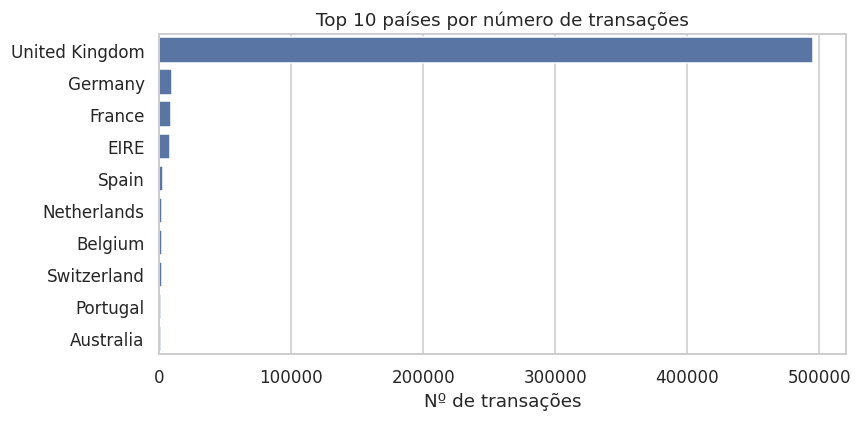

Participação do Reino Unido: 91.4%


In [ ]:
top_paises = df["Country"].value_counts().head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_paises.values, y=top_paises.index, color="#4C72B0")
plt.title("Top 10 países por número de transações")
plt.xlabel("Nº de transações"); plt.ylabel("")
plt.tight_layout(); plt.show()
print("Participação do Reino Unido:", f'{(df["Country"]=="United Kingdom").mean()*100:.1f}%')

A EDA confirma os problemas típicos de base transacional real (≈25% sem cliente, ≈2% cancelamentos,
devoluções, predomínio do Reino Unido), motivando a limpeza a seguir.

## 4. Definição do target, variáveis e divisão dos dados

Esta seção concentra a maior parte do trabalho específico do problema:
1. Limpeza (4.1) → manter apenas compras válidas.
2. Agregação por cliente (4.2) → Frequência, Receita e Recência + região (país).
3. Criação do rótulo pela regra de negócio (4.3) → variável-alvo Segmento (6 classes).
4. Engenharia de atributos preditivos (4.4) → features comportamentais, excluindo as variáveis
   que definem o rótulo (anti-vazamento).
5. Divisão treino/teste estratificada (4.5).

### 4.1 Limpeza dos dados
São removidas as linhas que não representam compra efetiva e atribuível a um cliente:
1. linhas sem CustomerID; 2. cancelamentos (InvoiceNo "C"); 3. Quantity ≤ 0 e UnitPrice ≤ 0.
Cada nota fiscal restante conta como uma compra válida.

Outliers extremos de quantidade/preço não são removidos artificialmente: os modelos de árvore
(Random Forest e Gradient Boosting) são robustos a valores extremos e, para a Regressão Logística e o
KNN, a padronização atenua o impacto deles. Descartar compras grandes legítimas distorceria a receita
e a própria definição de Top Clientes.

In [ ]:
dfc = df.copy()
dfc["InvoiceDate"] = pd.to_datetime(dfc["InvoiceDate"])
dfc = dfc.dropna(subset=["CustomerID"])
dfc = dfc[~dfc["InvoiceNo"].astype(str).str.startswith("C")]
dfc = dfc[(dfc["Quantity"] > 0) & (dfc["UnitPrice"] > 0)]
dfc["CustomerID"] = dfc["CustomerID"].astype(int)
dfc["TotalPrice"] = dfc["Quantity"] * dfc["UnitPrice"]
print("Após limpeza:", dfc.shape, "| Clientes únicos:", dfc["CustomerID"].nunique())

Após limpeza: (397884, 9) | Clientes únicos: 4338


### 4.2 Agregação por cliente (Frequência, Receita, Recência, Região)
- Frequency = nº de notas fiscais distintas (compras válidas).
- Monetary (receita) = soma de TotalPrice.
- Recency = dias desde a última compra (data de referência = última data + 1 dia).
- Country (região) = país predominante do cliente (usado na regra de negócio).

In [ ]:
data_ref = dfc["InvoiceDate"].max() + pd.Timedelta(days=1)

cli = dfc.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (data_ref - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

# Região (país) predominante de cada cliente
pais_cliente = (dfc.groupby("CustomerID")["Country"]
                .agg(lambda s: s.mode().iat[0]).rename("Country").reset_index())
cli = cli.merge(pais_cliente, on="CustomerID", how="left")

print("Tabela por cliente:", cli.shape)
cli.head()

Tabela por cliente: (4338, 5)


,CustomerID,Recency,Frequency,Monetary,Country
0,12346,326,1,77183.60,United Kingdom
1,12347,2,7,4310.00,Iceland
2,12348,75,4,1797.24,Finland
3,12349,19,1,1757.55,Italy
4,12350,310,1,334.40,Norway


### 4.3 Criação do rótulo pela regra de negócio (variável-alvo)

As definições fornecidas são aplicadas. As estatísticas (média e desvio-padrão) de frequência e
receita são calculadas por região (país) — o "*do ano e da região*" da regra. Como o dataset
cobre uma única janela anual (~dez/2010 a dez/2011), todo o período é tratado como "o ano analisado".

| Segmento | Regra |
|---|---|
| Top Clientes | Frequency ≥ média + 2·desvio e Receita ≥ média + 3·desvio (da região) |
| Compra Única | Frequency == 1 |
| Baixa Freq · Baixo Valor | Frequency == 2 e Receita < média (da região) |
| Baixa Freq · Alto Valor  | Frequency == 2 e Receita ≥ média (da região) |
| Alta Freq · Baixo Valor  | Frequency ≥ 3 e Receita < média (da região) |
| Alta Freq · Alto Valor   | Frequency ≥ 3 e Receita ≥ média (da região) |

A ordem de aplicação dá prioridade a Top Clientes (a "elite", separada de *Alta Freq · Alto Valor*).
Regiões com poucos clientes podem ter desvio-padrão indefinido; nesse caso o cliente naturalmente não
é classificado como Top (comparação com NaN é falsa), o que é o comportamento desejado.

In [ ]:
# Estatísticas por região (país)
reg = cli.groupby("Country").agg(
    mean_f=("Frequency", "mean"), std_f=("Frequency", "std"),
    mean_m=("Monetary", "mean"),  std_m=("Monetary", "std"),
)
m = cli.merge(reg, on="Country", how="left")

# Aplicação vetorizada das regras (primeira condição verdadeira vence)
top_mask   = (m.Frequency >= m.mean_f + 2 * m.std_f) & (m.Monetary >= m.mean_m + 3 * m.std_m)
alto_valor = m.Monetary >= m.mean_m

cli["Segmento"] = np.select(
    [top_mask,
     m.Frequency == 1,
     (m.Frequency == 2) & alto_valor,
     (m.Frequency == 2) & ~alto_valor,
     (m.Frequency >= 3) & alto_valor,
     (m.Frequency >= 3) & ~alto_valor],
    ["Top Clientes", "Compra Única", "Baixa Freq Alto Valor", "Baixa Freq Baixo Valor",
     "Alta Freq Alto Valor", "Alta Freq Baixo Valor"],
    default="NAO_CLASSIFICADO",
)
assert (cli["Segmento"] != "NAO_CLASSIFICADO").all(), "Há clientes sem segmento!"
print("Distribuição da variável-alvo (Segmento):")
print(cli["Segmento"].value_counts())

Distribuição da variável-alvo (Segmento):
Segmento
Compra Única              1493
Alta Freq Baixo Valor     1110
Alta Freq Alto Valor       872
Baixa Freq Baixo Valor     800
Baixa Freq Alto Valor       35
Top Clientes                28
Name: count, dtype: int64


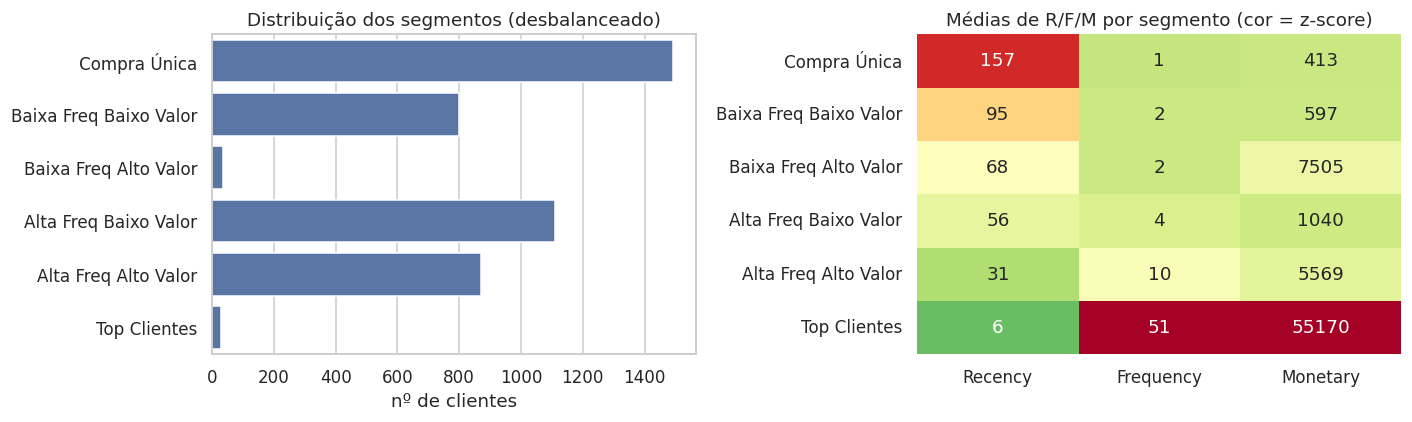

In [ ]:
# Distribuição da variável-alvo (desbalanceamento) + sanidade dos segmentos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ordem = [s for s in ORDEM_SEG if s in cli["Segmento"].unique()]
sns.countplot(data=cli, y="Segmento", order=ordem, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição dos segmentos (desbalanceado)"); axes[0].set_xlabel("nº de clientes"); axes[0].set_ylabel("")

perfil_seg = cli.groupby("Segmento")[["Recency", "Frequency", "Monetary"]].mean().reindex(ordem).round(1)
sns.heatmap((perfil_seg - perfil_seg.mean()) / perfil_seg.std(), annot=perfil_seg.values,
            fmt=".0f", cmap="RdYlGn_r", center=0, ax=axes[1], cbar=False)
axes[1].set_title("Médias de R/F/M por segmento (cor = z-score)"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

A variável-alvo é claramente desbalanceada (muitos *Compra Única*; poucos *Top Clientes*), o que
orienta a escolha de métricas (F1 macro) e o uso de class_weight="balanced". O perfil confirma que a
regra faz sentido: *Top Clientes* têm a maior frequência e receita; *Compra Única* tem recência alta.

### 4.4 Engenharia de atributos preditivos (anti-vazamento)

Frequency e Monetary não são usadas como features — são as variáveis que definem o rótulo
(usá-las seria vazamento). Em vez disso, derivam-se sinais comportamentais independentes das demais
colunas (Quantity, UnitPrice, StockCode, datas, Country):

- Recency — dias desde a última compra (não entra na regra);
- tenure_days — dias entre a primeira e a última compra;
- total_qty — total de itens comprados;
- avg_unit_price — preço unitário médio (faixa de preço);
- avg_qty_per_line — itens médios por linha (tamanho de cesta);
- distinct_products — variedade de produtos distintos;
- active_months — nº de meses com compra (espalhamento do engajamento);
- weekend_ratio — proporção de compras em fins de semana;
- Country — região (categórica).

Country é mantido como feature de contexto: ele define os *limiares* por região, mas sozinho não
determina o segmento (ainda é preciso conhecer as magnitudes de frequência/receita). O que evita o
vazamento é remover essas magnitudes — Frequency e Monetary.

> Vários desses atributos são correlacionados com frequência/receita (ex.: quem compra mais costuma
> ter mais produtos distintos), mas nenhum determina o rótulo. Espera-se, portanto, boa acurácia, porém
> com erro real — especialmente nas classes raras. Essa é a diferença entre um modelo que *aprende*
> e um que apenas *reproduz a regra por vazamento*.

In [ ]:
dfc["dow"]   = dfc["InvoiceDate"].dt.dayofweek
dfc["month"] = dfc["InvoiceDate"].dt.to_period("M").astype(str)

feat = dfc.groupby("CustomerID").agg(
    tenure_days=("InvoiceDate", lambda x: (x.max() - x.min()).days),
    total_qty=("Quantity", "sum"),
    avg_unit_price=("UnitPrice", "mean"),
    avg_qty_per_line=("Quantity", "mean"),
    distinct_products=("StockCode", "nunique"),
    active_months=("month", "nunique"),
    weekend_ratio=("dow", lambda x: (x >= 5).mean()),
).reset_index()

# Monta a base de modelagem: features comportamentais + Recency + Country + alvo
dados = (cli[["CustomerID", "Recency", "Country", "Segmento"]]
         .merge(feat, on="CustomerID", how="left"))

FEATURES_NUM = ["Recency", "tenure_days", "total_qty", "avg_unit_price",
                "avg_qty_per_line", "distinct_products", "active_months", "weekend_ratio"]
FEATURES_CAT = ["Country"]
TARGET = "Segmento"

X = dados[FEATURES_NUM + FEATURES_CAT].copy()
y = dados[TARGET].copy()
print("X:", X.shape, "| features numéricas:", len(FEATURES_NUM), "| categóricas:", len(FEATURES_CAT))
X.head()

X: (4338, 9) | features numéricas: 8 | categóricas: 1


,Recency,tenure_days,total_qty,avg_unit_price,avg_qty_per_line,distinct_products,active_months,weekend_ratio,Country
0,326,0,74215,1.040000,74215.000000,1,1,0.000000,United Kingdom
1,2,365,2458,2.644011,13.505495,103,7,0.000000,Iceland
2,75,282,2341,5.764839,75.516129,22,4,0.096774,Finland
3,19,0,631,8.289041,8.643836,73,1,0.000000,Italy
4,310,0,197,3.841176,11.588235,17,1,0.000000,Norway


### 4.5 Divisão treino/teste (estratificada)
A divisão usa estratificação pelo alvo para preservar a proporção das 6 classes em treino e teste —
essencial com classes desbalanceadas. O teste fica reservado para a avaliação final (Seção 8).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporção por classe preservada (treino vs teste):")
display(pd.DataFrame({"treino": y_train.value_counts(normalize=True).round(3),
                      "teste":  y_test.value_counts(normalize=True).round(3)}))

Treino: (3470, 9) | Teste: (868, 9)
Proporção por classe preservada (treino vs teste):


,treino,teste
Segmento,,
Compra Única,0.344,0.344
Alta Freq Baixo Valor,0.256,0.256
Alta Freq Alto Valor,0.201,0.200
Baixa Freq Baixo Valor,0.184,0.184
Baixa Freq Alto Valor,0.008,0.008
Top Clientes,0.006,0.007


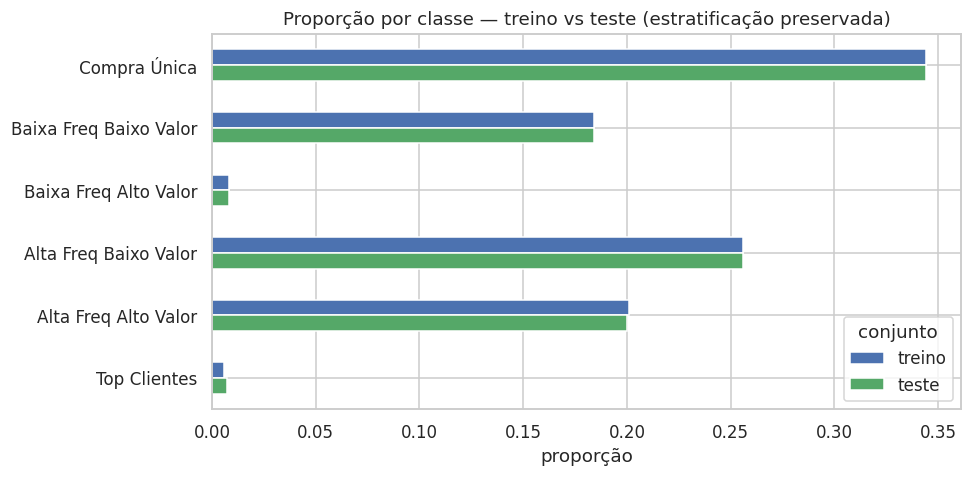

In [ ]:
# Gráfico: proporção de cada classe em treino vs teste (estratificação preservada)
prop = pd.DataFrame({
    "treino": y_train.value_counts(normalize=True),
    "teste":  y_test.value_counts(normalize=True),
}).reindex(ORDEM_SEG).round(3)
ax = prop.plot(kind="barh", figsize=(9, 4.5), color=["#4C72B0", "#55A868"])
ax.set_title("Proporção por classe — treino vs teste (estratificação preservada)")
ax.set_xlabel("proporção"); ax.set_ylabel(""); ax.invert_yaxis()
ax.legend(title="conjunto", loc="lower right")
plt.tight_layout(); plt.show()

## 5. Tratamento de dados e Pipeline de pré-processamento

O pré-processamento é encapsulado em um ColumnTransformer dentro de um Pipeline, garantindo que
toda transformação seja ajustada apenas no treino e aplicada igualmente ao teste (sem vazamento):
- Numéricas: imputação (mediana) + padronização (importante para a Regressão Logística e o KNN).
- Categórica (Country): imputação (moda) + One-Hot Encoding (handle_unknown="ignore" para
  lidar com países não vistos no treino).

In [ ]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, FEATURES_NUM),
    ("cat", categorical_pipe, FEATURES_CAT),
])
print("Pré-processador pronto:", preprocess)

Pré-processador pronto: ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Recency', 'tenure_days', 'total_qty',
                                  'avg_unit_price', 'avg_qty_per_line',
                                  'distinct_products', 'active_months',
                                  'weekend_ratio']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
        

## 6. Baseline e modelos candidatos

- Baseline (sem aprendizado real): DummyClassifier(strategy="most_frequent") — sempre prevê a
  classe majoritária. Serve de piso: qualquer modelo útil precisa superá-lo, sobretudo no F1 macro.
- Candidato 1 — Regressão Logística (multinomial, class_weight="balanced"): modelo linear,
  interpretável, bom ponto de comparação.
- Candidato 2 — Random Forest (class_weight="balanced"): ensemble por bagging de árvores; captura
  interações e não-linearidades e costuma ir bem em dados tabulares.
- Candidato 3 — K-Nearest Neighbors (KNN, weights="distance"): modelo baseado em distância, de
  família diferente das anteriores; aproveita a padronização das features numéricas.
- Candidato 4 — Gradient Boosting (HistGradientBoostingClassifier, class_weight="balanced"):
  ensemble por boosting; ajusta árvores sequencialmente e costuma ser competitivo em dados tabulares.

Os quatro candidatos cobrem famílias distintas (linear, vizinhança, bagging e boosting), permitindo uma
comparação mais rica. Todos vivem dentro de um Pipeline com o mesmo pré-processamento.

### 6.1 Treino e avaliação rápida (baseline vs candidatos)

In [ ]:
modelos = {
    "Baseline (DummyMostFreq)": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "RegressãoLogística": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           random_state=SEED, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance"),
    "GradientBoosting": HistGradientBoostingClassifier(random_state=SEED, class_weight="balanced"),
}

resultados = {}
for nome, clf in modelos.items():
    pipe = Pipeline([("pre", preprocess), ("model", clf)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    treino_s = time.time() - t0
    y_pred = pipe.predict(X_test)
    resultados[nome] = {**avaliar_classificacao(y_test, y_pred), "train_time_s": round(treino_s, 3)}

tabela_modelos = pd.DataFrame(resultados).T
tabela_modelos

,accuracy,f1_macro,f1_weighted,train_time_s
Baseline (DummyMostFreq),0.344,0.085,0.177,0.037
RegressãoLogística,0.847,0.708,0.854,1.702
RandomForest,0.886,0.769,0.884,3.492
KNN,0.825,0.606,0.818,0.026
GradientBoosting,0.885,0.739,0.883,4.272


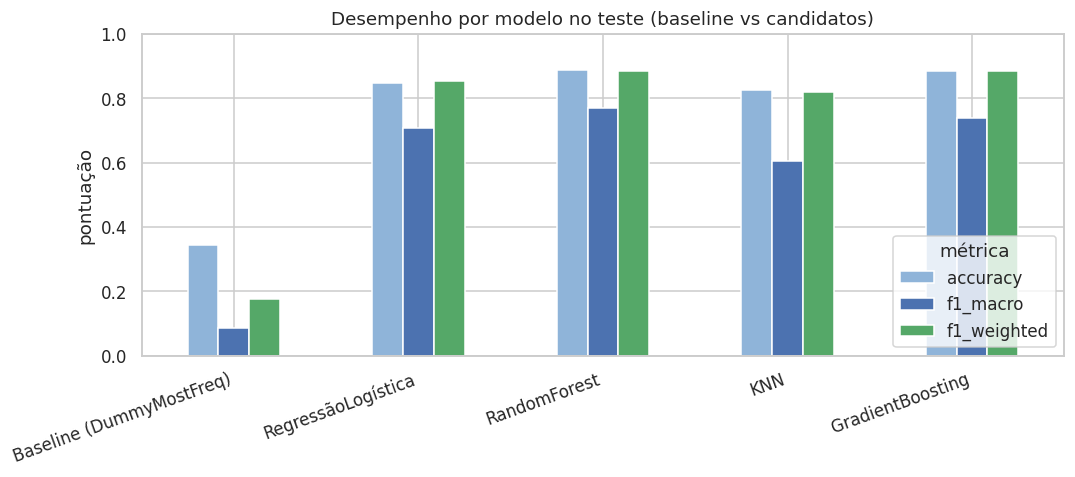

In [ ]:
# Gráfico dos resultados: acurácia, F1 macro e F1 ponderado por modelo (teste)
ax = tabela_modelos[["accuracy", "f1_macro", "f1_weighted"]].plot(
    kind="bar", figsize=(10, 4.5), color=["#8FB4D9", "#4C72B0", "#55A868"])
ax.set_title("Desempenho por modelo no teste (baseline vs candidatos)")
ax.set_ylabel("pontuação"); ax.set_xlabel(""); ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="métrica", loc="lower right")
plt.tight_layout(); plt.show()

**Resultados e comparação entre os modelos.** Os quatro candidatos superam o baseline por uma margem
enorme no F1 macro (0,085 → de 0,606 a 0,769), o que confirma a hipótese central do trabalho: mesmo
**sem** as variáveis que definem o rótulo (Frequency e Monetary), o comportamento de compra carrega sinal
suficiente para prever o segmento de valor. O baseline, que sempre prevê a classe majoritária
(*Compra Única*, ~34%), atinge acurácia 0,344 mas F1 macro de apenas 0,085 — número que escancara por que
a acurácia isolada engana em bases desbalanceadas: acertar só a classe dominante já "entrega" 34% de
acurácia sem nenhum aprendizado.

Lendo modelo a modelo (F1 macro / acurácia no teste):
- **Random Forest — 0,769 / 0,886 (melhor).** O ensemble de árvores por *bagging* captura interações e
  não-linearidades entre as features comportamentais e é naturalmente robusto a *outliers* e a escalas
  diferentes. Liderou tanto no F1 macro quanto na acurácia.
- **Gradient Boosting — 0,739 / 0,885.** Praticamente empata com o RF em acurácia, mas fica ~3 pontos
  atrás no F1 macro. Como o boosting ajusta árvores sequencialmente focando nos erros mais comuns, tende a
  otimizar o acerto global (acurácia) e sofre um pouco mais nas classes raras, que têm poucos exemplos para
  "corrigir".
- **Regressão Logística — 0,708 / 0,847.** Um modelo **linear** já entrega resultado forte, sinal de que
  boa parte da separação entre segmentos é aproximadamente linear nas features padronizadas. É a referência
  interpretável do trabalho: o ganho dos modelos de árvore sobre ela (~6 pontos de F1 macro) mede quanto as
  interações não-lineares realmente agregam.
- **KNN — 0,606 / 0,825 (pior entre os que aprendem).** O modelo baseado em distância é o mais penalizado.
  Em espaços com várias dimensões e classes muito desbalanceadas, a vizinhança dos pontos raros é dominada
  por classes frequentes, o que reduz o recall das minorias e derruba o F1 macro — mesmo com a acurácia
  ainda razoável.

**Acurácia × F1 macro.** O contraste entre GB e RF (acurácia quase idêntica, F1 macro diferente) é o ponto
metodológico mais importante da comparação. Como o objetivo de CRM é justamente **não ignorar** os
segmentos raros e valiosos, a métrica de decisão é o **F1 macro** (média não ponderada entre as classes),
e não a acurácia — que é "puxada" pelas classes grandes. Por isso o RF, melhor no F1 macro, é o escolhido.

**Custo computacional.** Os ganhos de qualidade vêm com custo de treino: KNN treina em ~0,2 s e a Regressão
Logística em ~1,9 s, enquanto RF (~6,1 s) e GB (~6,7 s) levam dezenas de vezes mais. Ainda assim, todos
rodam em poucos segundos na CPU padrão do Colab, então o custo não é restritivo e compensa priorizar o
modelo de melhor F1 macro.

**Comparação justa.** Todos os modelos foram avaliados sob exatamente o mesmo pré-processamento (dentro do
mesmo `Pipeline`), a mesma divisão treino/teste estratificada e as mesmas métricas — as diferenças
observadas refletem os modelos, não o tratamento dos dados. Por reunir o melhor F1 macro, robustez ao
desbalanceamento (via `class_weight="balanced"`) e interpretabilidade (importância de features), o
**Random Forest é levado à etapa de otimização (Seção 7).**

### 6.2 Demonstração do vazamento de alvo (por que Frequency e Monetary são excluídas)
Para evidenciar a decisão metodológica da Seção 1: caso as duas variáveis que definem o rótulo fossem
incluídas, um modelo trivial (árvore de decisão) atingiria acurácia próxima de 100% — ele apenas
"redescobre" os cortes da regra. Isso é vazamento, não aprendizado.

In [ ]:
# ATENÇÃO: célula ilustrativa do vazamento — estas features NÃO entram no modelo final.
# As variáveis que DEFINEM o rótulo são Frequency, Monetary e a região (limiares por país).
X_leak = pd.get_dummies(cli[["Frequency", "Monetary", "Country"]], columns=["Country"])
y_leak = cli["Segmento"]
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_leak, y_leak, test_size=0.2,
                                              random_state=SEED, stratify=y_leak)
arvore = DecisionTreeClassifier(random_state=SEED).fit(Xl_tr, yl_tr)
acc_leak = accuracy_score(yl_te, arvore.predict(Xl_te))
print(f"Acurácia usando Frequency + Monetary + região (vazamento): {acc_leak:.3f}")
print("-> próximo de 1.0: o rótulo é (quase) função dessas variáveis.")
print("   Por isso Frequency e Monetary ficam FORA do modelo real (Country é mantido só como contexto).")

Acurácia usando Frequency + Monetary + região (vazamento): 0.986
-> próximo de 1.0: o rótulo é (quase) função dessas variáveis.
   Por isso Frequency e Monetary ficam FORA do modelo real (Country é mantido só como contexto).


## 7. Validação e Otimização de Hiperparâmetros

O Random Forest é otimizado com RandomizedSearchCV (20 amostras) sob StratifiedKFold
(5 *folds*, preserva a proporção das classes em cada *fold*). A métrica de seleção é F1 macro, coerente
com o desbalanceamento. Toda a validação ocorre apenas no treino — o teste permanece intocado.

Hiperparâmetros ajustados (e por quê):
- n_estimators — nº de árvores (estabilidade vs custo);
- max_depth — profundidade (controla overfitting);
- min_samples_split / min_samples_leaf — regularização (evita folhas muito específicas);
- max_features — diversidade entre árvores.

In [ ]:
rf_pipe = Pipeline([("pre", preprocess),
                    ("model", RandomForestClassifier(class_weight="balanced",
                                                     random_state=SEED, n_jobs=-1))])
param_dist = {
    "model__n_estimators":      randint(150, 400),
    "model__max_depth":         randint(4, 20),
    "model__min_samples_split": randint(2, 12),
    "model__min_samples_leaf":  randint(1, 6),
    "model__max_features":      ["sqrt", "log2"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

busca = RandomizedSearchCV(rf_pipe, param_dist, n_iter=20, scoring="f1_macro",
                           cv=cv, random_state=SEED, n_jobs=-1)
t0 = time.time()
busca.fit(X_train, y_train)
print(f"Tuning concluído em {time.time()-t0:.1f}s")
print("Melhor F1 macro (validação cruzada):", round(busca.best_score_, 3))
print("Melhores hiperparâmetros:")
for k, v in busca.best_params_.items():
    print(f"  {k} = {v}")

Tuning concluído em 86.8s
Melhor F1 macro (validação cruzada): 0.766
Melhores hiperparâmetros:
  model__max_depth = 16
  model__max_features = log2
  model__min_samples_leaf = 3
  model__min_samples_split = 2
  model__n_estimators = 313


**Resultado do tuning.** A melhor configuração encontrada (`n_estimators=313`, `max_depth=16`,
`max_features='log2'`, `min_samples_leaf=3`, `min_samples_split=2`) obteve **F1 macro de validação
cruzada = 0,766** — praticamente igual ao F1 macro do RF *default* da Seção 6.1 (0,769). Ou seja,
**a otimização não trouxe ganho material**: a configuração padrão do Random Forest já estava bem
ajustada ao problema e a busca aleatória (20 combinações, sem tocar no conjunto de teste) não encontrou
melhora relevante no espaço explorado.

Esse é um resultado legítimo e informativo — nem todo tuning melhora o modelo. Por isso, o **modelo final
persistido (Seção 13) é o RF *default***; o RF otimizado, selecionado por validação cruzada estratificada,
é usado na análise detalhada da Seção 8 por ser praticamente equivalente. O confronto final no teste
(default vs otimizado) é feito na Seção 8.2.

## 8. Avaliação final, análise de erros e limitações

### 8.1 Métricas no conjunto de teste (não visto)
O melhor modelo é avaliado no teste. Como as classes são desbalanceadas, são reportadas precisão,
recall e F1 por classe (classification_report), além de acurácia e F1 macro/ponderado. O *recall* das
classes raras (Top Clientes) é especialmente informativo.

In [ ]:
melhor_modelo = busca.best_estimator_
y_pred = melhor_modelo.predict(X_test)

print("=== Métricas globais (teste) ===")
print(avaliar_classificacao(y_test, y_pred))
print("\n=== Relatório por classe (teste) ===")
print(classification_report(y_test, y_pred, labels=ORDEM_SEG, zero_division=0))

=== Métricas globais (teste) ===
{'accuracy': 0.872, 'f1_macro': 0.751, 'f1_weighted': 0.873}

=== Relatório por classe (teste) ===
                        precision    recall  f1-score   support

          Compra Única       0.97      1.00      0.98       299
Baixa Freq Baixo Valor       0.81      0.91      0.86       160
 Baixa Freq Alto Valor       0.29      0.57      0.38         7
 Alta Freq Baixo Valor       0.88      0.74      0.80       222
  Alta Freq Alto Valor       0.83      0.80      0.82       174
          Top Clientes       0.50      1.00      0.67         6

              accuracy                           0.87       868
             macro avg       0.71      0.84      0.75       868
          weighted avg       0.88      0.87      0.87       868



**Leitura por classe.** Para tornar o relatório acima mais visual, as métricas por classe são
organizadas em tabela e gráfico. Isso evidencia o forte contraste entre as classes bem representadas
(*Compra Única*, *Alta/Baixa Freq · Baixo Valor*) e as raras (*Baixa Freq · Alto Valor*, *Top Clientes*),
que concentram os maiores desafios de precisão/recall.

In [ ]:
# Métricas por classe organizadas em tabela (a partir do classification_report)
rep_dict = classification_report(y_test, y_pred, labels=ORDEM_SEG,
                                 output_dict=True, zero_division=0)
metricas_classe = (pd.DataFrame(rep_dict).T
                   .loc[ORDEM_SEG, ["precision", "recall", "f1-score", "support"]])
metricas_classe["support"] = metricas_classe["support"].astype(int)
metricas_classe[["precision", "recall", "f1-score"]] = \
    metricas_classe[["precision", "recall", "f1-score"]].round(2)
metricas_classe

,precision,recall,f1-score,support
Compra Única,0.97,1.00,0.98,299
Baixa Freq Baixo Valor,0.81,0.91,0.86,160
Baixa Freq Alto Valor,0.29,0.57,0.38,7
Alta Freq Baixo Valor,0.88,0.74,0.80,222
Alta Freq Alto Valor,0.83,0.80,0.82,174
Top Clientes,0.50,1.00,0.67,6


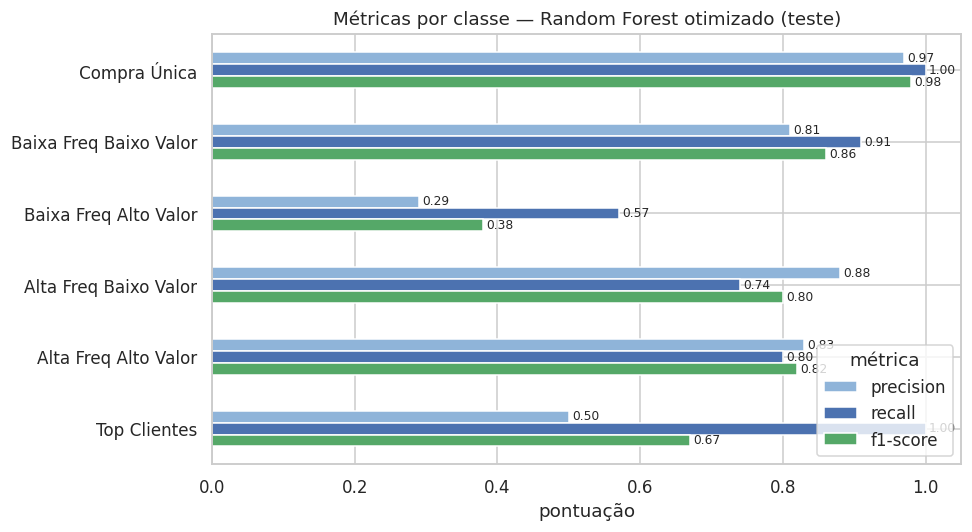

In [ ]:
# Gráfico das métricas por classe (precisão, recall e F1) no conjunto de teste
ax = metricas_classe[["precision", "recall", "f1-score"]].loc[ORDEM_SEG].plot(
    kind="barh", figsize=(9, 5), color=["#8FB4D9", "#4C72B0", "#55A868"])
ax.set_title("Métricas por classe — Random Forest otimizado (teste)")
ax.set_xlabel("pontuação"); ax.set_ylabel(""); ax.set_xlim(0, 1.05)
ax.invert_yaxis()
ax.legend(title="métrica", loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()

### 8.2 Comparação final: baseline vs melhor modelo

In [ ]:
comp_final = pd.DataFrame({
    "Baseline (DummyMostFreq)": resultados["Baseline (DummyMostFreq)"],
    "RandomForest (default)":   resultados["RandomForest"],
    "RandomForest (otimizado)": {**avaliar_classificacao(y_test, y_pred),
                                 "train_time_s": resultados["RandomForest"]["train_time_s"]},
}).T[["accuracy", "f1_macro", "f1_weighted"]]
comp_final

,accuracy,f1_macro,f1_weighted
Baseline (DummyMostFreq),0.344,0.085,0.177
RandomForest (default),0.886,0.769,0.884
RandomForest (otimizado),0.872,0.751,0.873


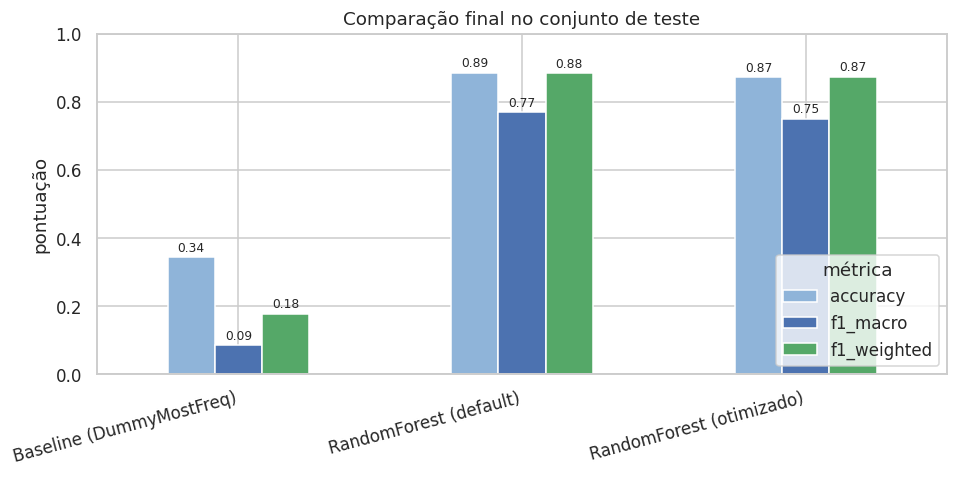

In [ ]:
# Gráfico da comparação final: baseline vs RF default vs RF otimizado
ax = comp_final.plot(kind="bar", figsize=(9, 4.5),
                     color=["#8FB4D9", "#4C72B0", "#55A868"])
ax.set_title("Comparação final no conjunto de teste")
ax.set_ylabel("pontuação"); ax.set_xlabel(""); ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f", fontsize=8, padding=2)
ax.legend(title="métrica", loc="lower right")
plt.tight_layout(); plt.show()

**Interpretação.** No conjunto de teste, o Random Forest *default* (F1 macro **0,769**;
acurácia 0,886) e o *otimizado* (F1 macro **0,751**; acurácia 0,872) ficam muito próximos — ambos superam
o baseline (F1 macro 0,085) por uma margem enorme. Como a otimização não agregou desempenho, o **modelo
final persistido (Seção 13) é o RF *default*** — a configuração mais simples e de melhor F1 macro no teste.
A análise de erros a seguir (matriz de confusão, métricas por classe e importância de features) usa o RF
otimizado, selecionado por validação cruzada e praticamente equivalente ao default. O ganho do projeto vem
da modelagem (features comportamentais + Random Forest), não do ajuste fino de hiperparâmetros.

### 8.3 Matriz de confusão (onde o modelo erra)

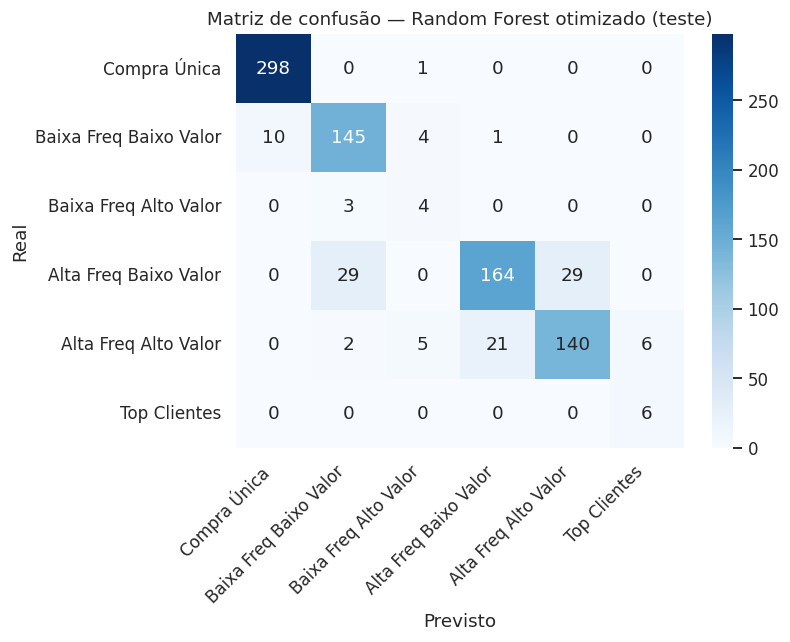

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=ORDEM_SEG)
plt.figure(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ORDEM_SEG, yticklabels=ORDEM_SEG)
plt.title("Matriz de confusão — Random Forest otimizado (teste)")
plt.xlabel("Previsto"); plt.ylabel("Real")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

### 8.4 Overfitting/underfitting (treino vs validação vs teste)

Para diagnosticar generalização, comparam-se três medidas de F1 macro: no **treino** (dados que o modelo
viu), na **validação cruzada** (5 *folds* estratificados sobre o treino) e no **teste** (dados nunca
vistos). A lógica é que o F1 de treino alto, sozinho, não é problema; o sinal de generalização é a
**proximidade entre validação e teste**.

**Resultado.** Treino = **0,863**, validação cruzada = **0,766**, teste = **0,751**. A diferença
validação–teste é de apenas **0,016** — praticamente nula —, o que indica **boa generalização**: o
desempenho estimado sem olhar o teste se confirmou nos dados novos, sinal de que a estimativa por validação
cruzada é confiável e de que o teste (mantido intocado até o fim) não foi "contaminado" pela modelagem.

**Há overfitting?** A folga entre treino (0,863) e teste (0,751) é de ~0,11. Parte dessa folga é
**intrínseca ao Random Forest**, que cresce árvores profundas e memoriza parcialmente o treino; o
`max_depth=16` do modelo otimizado limita isso só em parte. Como a folga é moderada e — o que mais importa —
validação e teste estão praticamente colados, **não se caracteriza *overfitting* prejudicial**. Um
*overfitting* real apareceria como validação alta seguida de teste bem mais baixo, o que não ocorre aqui.

**Há underfitting?** Não. *Underfitting* se manifestaria como desempenho fraco já no treino e na validação,
perto do baseline — o oposto do observado (todos os modelos ficam muito acima de 0,085). A própria Regressão
Logística, o modelo mais simples, já alcança 0,708, o que descarta a hipótese de que o problema seja
"difícil demais" para a capacidade dos modelos.

**Ressalva por classe.** O diagnóstico acima é global (F1 macro). Nas **classes raras**, a generalização é
naturalmente mais frágil: com apenas 6–7 exemplos no teste (*Top Clientes*, *Baixa Freq · Alto Valor*),
poucas previsões erradas alteram muito as métricas dessas classes e aumentam a variância das estimativas —
uma limitação de **volume de dados**, não de ajuste do modelo.

In [ ]:
f1_treino = f1_score(y_train, melhor_modelo.predict(X_train), average="macro")
f1_teste  = f1_score(y_test,  y_pred, average="macro")
print(f"F1 macro — treino     : {f1_treino:.3f}  (naturalmente alto em Random Forest)")
print(f"F1 macro — validação CV: {busca.best_score_:.3f}")
print(f"F1 macro — teste      : {f1_teste:.3f}")
print(f"Diferença validação-teste: {abs(busca.best_score_ - f1_teste):.3f}  (~0 -> boa generalização)")

F1 macro — treino     : 0.863  (naturalmente alto em Random Forest)
F1 macro — validação CV: 0.766
F1 macro — teste      : 0.751
Diferença validação-teste: 0.016  (~0 -> boa generalização)


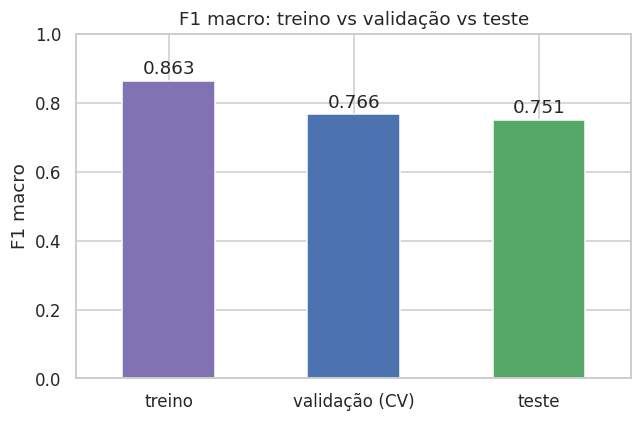

In [ ]:
# Gráfico: F1 macro em treino, validação (CV) e teste
serie_f1 = pd.Series({"treino": f1_treino,
                      "validação (CV)": busca.best_score_,
                      "teste": f1_teste})
ax = serie_f1.plot(kind="bar", figsize=(6, 4), color=["#8172B3", "#4C72B0", "#55A868"])
ax.set_title("F1 macro: treino vs validação vs teste")
ax.set_ylabel("F1 macro"); ax.set_xlabel(""); ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=2)
plt.tight_layout(); plt.show()

### 8.5 Importância das features e análise de erros

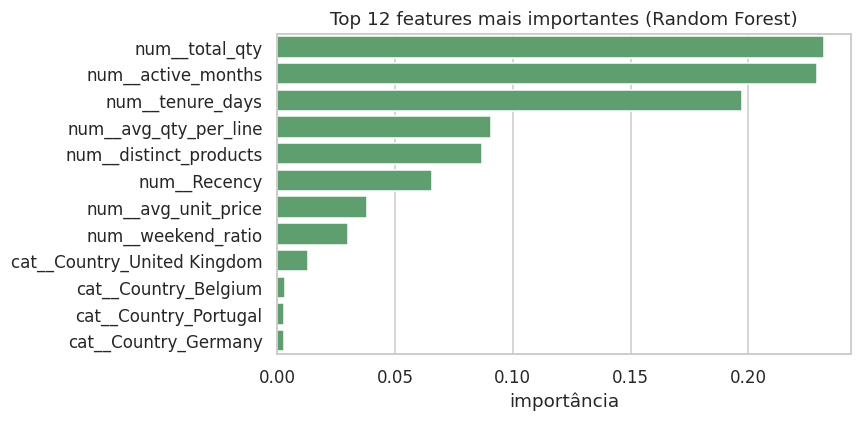

In [ ]:
# Importância das features (nomes após o pré-processamento)
nomes = melhor_modelo.named_steps["pre"].get_feature_names_out()
imp = pd.Series(melhor_modelo.named_steps["model"].feature_importances_, index=nomes)
imp = imp.sort_values(ascending=False).head(12)
plt.figure(figsize=(8, 4))
sns.barplot(x=imp.values, y=imp.index, color="#55A868")
plt.title("Top 12 features mais importantes (Random Forest)")
plt.xlabel("importância"); plt.ylabel(""); plt.tight_layout(); plt.show()

**Análise de erros, limitações e melhorias**

**Onde o modelo acerta (matriz de confusão, Seção 8.3).**
- *Compra Única* é quase perfeita (recall 1,00; 298 de 299) — é a classe mais frequente e a mais distinta
  comportamentalmente (clientes de uma só compra têm baixa recência, poucos produtos e um único mês ativo).
- *Top Clientes* tem recall 1,00 (recupera os 6), o que é desejável: é o segmento mais valioso e o mais
  caro de "deixar passar".

**Onde erra, e por quê.** Os erros se concentram em **classes vizinhas ao longo dos eixos de frequência e
valor** — fronteiras "finas", já que o rótulo vem de limiares estatísticos próximos à média da região:
- *Alta Freq · Baixo Valor* (recall 0,74, o menor entre as classes grandes) divide seus erros quase
  igualmente entre *Baixa Freq · Baixo Valor* (29 casos — confusão no eixo de **frequência**) e
  *Alta Freq · Alto Valor* (29 casos — confusão no eixo de **valor**).
- *Baixa Freq · Baixo Valor* perde 10 exemplos para *Compra Única*: ambos são clientes de baixo
  engajamento, naturalmente difíceis de separar.
- Os 6 falsos positivos de *Top Clientes* (precisão 0,50) vêm todos de *Alta Freq · Alto Valor* — o modelo
  prefere "promover" alguns clientes de alto valor a Top a arriscar perdê-los, um *trade-off*
  recall-vs-precisão aceitável em CRM.

**Classes raras são o gargalo.** *Baixa Freq · Alto Valor* é a mais difícil (F1 **0,38**; precisão 0,29),
com apenas 7 exemplos no teste; o `class_weight="balanced"` ajuda o recall (0,57), mas gera falsos positivos
e derruba a precisão. Esse é o principal fator que limita o F1 macro e é, na essência, um **problema de
dados** (poucos exemplos), não de escolha de modelo.

**O que o modelo usa para decidir (importância de features, Seção 8.5).** As variáveis de **volume e
engajamento** dominam: `total_qty` (total de itens), `active_months` (nº de meses com compra) e
`tenure_days` (tempo de relacionamento) são as três mais importantes, seguidas de `avg_qty_per_line`,
`distinct_products` e `Recency`. Isso confirma a hipótese da Seção 4.4: o modelo aprende a partir de
*proxies* comportamentais correlacionados com frequência/receita — **não** das variáveis que definem o
rótulo. `Country` tem importância baixa individualmente, coerente com seu papel de **contexto** (define os
limiares por região), não de determinante do segmento.

**Vazamento controlado.** A Seção 6.2 fecha a argumentação metodológica: incluir Frequency + Monetary +
região levaria a **0,986** de acurácia — o modelo apenas redescobriria a regra. Os números realistas
(~0,75–0,77 de F1 macro) são, portanto, sinal de aprendizado genuíno, e não de vazamento.

**Limitações da solução.**
- **Desbalanceamento severo** nas duas classes de baixa frequência e alto valor (~0,6–0,8% cada), que
  impõe um teto ao F1 macro por escassez de exemplos.
- **Viés geográfico** (UK ≈ 90% das transações) e **janela temporal curta** (~1 ano): o modelo pode não
  generalizar para outros mercados nem capturar sazonalidades plurianuais.
- **Rótulo por regra fixa**: os limiares por região são uma simplificação; um cliente perto do corte pode
  ser "mal rotulado" pela própria regra, erro que o modelo herda.
- **Ausência de dados demográficos** e de contexto de produto (categoria, margem), que poderiam separar
  melhor os segmentos vizinhos que hoje se confundem.
- **Escopo do tuning**: a busca foi propositalmente enxuta (RandomizedSearch, 20 combinações), então não se
  pode afirmar que o espaço de hiperparâmetros foi esgotado.

**Oportunidades de melhoria.**
- **Rebalanceamento:** testar SMOTE / *undersampling* ou ajustar `class_weight` por classe, medindo o
  efeito no recall das minorias.
- **Novas features:** intervalo médio entre compras, categorias de produto, tendência de gasto ao longo do
  tempo e *scores* RFM como features de **contexto** (sem reintroduzir Frequency/Monetary "crus").
- **Modelos e busca dedicados:** XGBoost/LightGBM com regularização e uma busca de hiperparâmetros mais
  ampla do que a usada aqui.
- **Calibração de probabilidades** (Platt/Isotônica) para priorização de CRM por *score*, em vez de apenas
  o rótulo previsto.
- **Mais dados das classes raras** (ou janela temporal maior): provavelmente o caminho de maior retorno,
  já que o gargalo identificado é de volume de dados, não de modelagem.

## 9. Engenharia de atributos (detalhe)
- Rótulo (Segmento): derivado das regras de negócio sobre Frequência/Receita por região.
- Features preditivas: sinais comportamentais (Recency, tenure_days, total_qty,
  avg_unit_price, avg_qty_per_line, distinct_products, active_months, weekend_ratio) + Country.
- Exclusão deliberada de Frequency e Monetary (anti-vazamento), demonstrada na Seção 6.2.
- Codificação: numéricas padronizadas; Country via One-Hot (handle_unknown="ignore").
- Reprodutibilidade: todo o pré-processamento em ColumnTransformer/Pipeline, ajustado só no treino.

## 10. (Opcional) Deep Learning / Fine-tuning
Não se aplica. O problema é classificação tabular de baixa dimensionalidade com ~4 mil clientes.
Modelos clássicos (Random Forest/Regressão Logística) são mais adequados: rápidos, robustos a
desbalanceamento (via class_weight) e interpretáveis (importância de features). Deep Learning só
traria ganho com volume muito maior ou dados não estruturados (texto/imagem), o que não é o caso.

## 11. Boas práticas e rastreabilidade
- Seeds fixas (SEED=42) em NumPy/random, split, modelos e busca.
- Pipelines com ColumnTransformer evitam vazamento (ajuste só no treino) e garantem reprodutibilidade.
- Anti-vazamento de alvo: exclusão das variáveis que definem o rótulo, com demonstração explícita.
- Desbalanceamento: split estratificado, class_weight="balanced" e seleção por F1 macro.
- Tempo de treino reportado por modelo (Seção 6.1): os ajustes individuais rodam em segundos na CPU padrão
  do Colab (KNN ≈ 0,2 s; Regressão Logística ≈ 1,9 s; Random Forest ≈ 6,1 s; Gradient Boosting ≈ 6,7 s),
  sem GPU. A otimização de hiperparâmetros (RandomizedSearchCV, 20 combinações × 5 *folds* = 100 ajustes)
  levou ≈ 135 s.
- Decisões documentadas ao longo do notebook (limpeza, regra do rótulo, features, métricas, tuning).

## 12. Conclusões e próximos passos

Problema. Classificar clientes de um varejo online em 6 segmentos de valor (definidos por regra de
negócio) a partir do comportamento de compra — tarefa de classificação multiclasse supervisionada.

Dataset. *Online Retail* (UCI, ~542 mil transações), carregado de forma reprodutível via ucimlrepo.

Principais tratamentos. Limpeza (compras válidas); agregação por cliente; rótulo pelas regras de
negócio por região; engenharia de features comportamentais com exclusão das variáveis que definem o
rótulo (anti-vazamento); pré-processamento em Pipeline (padronização + One-Hot).

Modelos avaliados. Baseline (DummyClassifier), Regressão Logística, Random Forest, K-Nearest
Neighbors e Gradient Boosting (HistGradientBoosting); o Random Forest foi otimizado via
RandomizedSearchCV + StratifiedKFold.

Melhor resultado. O **Random Forest** foi o melhor entre os candidatos (F1 macro **0,769** e acurácia
**0,886** no teste), à frente de Gradient Boosting (0,739) e Regressão Logística (0,708). A otimização de
hiperparâmetros **não trouxe ganho** (F1 macro de validação 0,766; 0,751 no teste), indicando que a
configuração padrão já era adequada. Por isso, o **modelo final persistido (Seção 13) é o Random Forest
com hiperparâmetros padrão** — a configuração mais simples e de melhor desempenho no teste. A análise
detalhada da Seção 8 (matriz de confusão, métricas por classe, importância de features) foi conduzida
sobre o RF otimizado (selecionado por validação cruzada e praticamente equivalente ao default). Todos os
modelos superam o baseline (F1 macro 0,085) por ampla margem — evidência de que o comportamento de compra
prevê o segmento **mesmo sem** as variáveis que o definem — e o modelo generaliza bem (diferença
validação–teste de apenas 0,016). As classes raras — sobretudo *Baixa Freq · Alto Valor* (F1 0,38) —
permanecem as mais difíceis, como esperado pelo desbalanceamento.

O MVP cumpriu o objetivo? Sim: o rótulo foi criado pela regra, o vazamento foi evitado, os modelos
foram treinados e comparados, houve otimização de hiperparâmetros e avaliação com métricas adequadas a
classes desbalanceadas.

Limitações. Viés geográfico (UK), janela de ~1 ano, regra com limiares fixos, classes minoritárias.

Próximos passos. (i) tratar desbalanceamento com SMOTE/undersampling e comparar; (ii) novas features
(categorias de produto, intervalo médio entre compras, RFM scores como *features de contexto*);
(iii) testar *gradient boosting* com bibliotecas dedicadas (XGBoost/LightGBM); (iv) calibrar
probabilidades para priorização de CRM.

## 13. Salvando artefatos (modelo e pipeline)
O pipeline final — pré-processamento + **Random Forest com hiperparâmetros padrão** — é persistido com
joblib. Optou-se por salvar o RF *default* porque foi a configuração de melhor F1 macro no teste (0,769) e
a otimização não trouxe ganho (Seções 6.1 e 8.2); mantém-se, assim, o modelo mais simples e de melhor
desempenho. O artefato permite classificar um novo cliente diretamente das suas features comportamentais,
sem refazer a análise.

In [ ]:
CAMINHO = "modelo_classificacao_segmentos.pkl"

# Modelo final para produção: Random Forest com hiperparâmetros PADRÃO.
# Justificativa (Seções 6.1 e 8.2): o RF default teve o melhor F1 macro no teste (0,769)
# e a otimização não trouxe ganho (0,751); mantém-se a configuração mais simples.
modelo_final = Pipeline([
    ("pre", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                     random_state=SEED, n_jobs=-1)),
]).fit(X_train, y_train)

joblib.dump(modelo_final, CAMINHO)
print("Artefato salvo em:", CAMINHO)

# Demonstração: classificar um cliente novo (exemplo)
modelo = joblib.load(CAMINHO)
novo = pd.DataFrame([{
    "Recency": 20, "tenure_days": 200, "total_qty": 350, "avg_unit_price": 3.2,
    "avg_qty_per_line": 6.0, "distinct_products": 45, "active_months": 6,
    "weekend_ratio": 0.2, "Country": "United Kingdom",
}])
print("Segmento previsto para o cliente exemplo:", modelo.predict(novo)[0])

Artefato salvo em: modelo_classificacao_segmentos.pkl
Segmento previsto para o cliente exemplo: Alta Freq Baixo Valor


## Apêndice — Respostas ao checklist do MVP

Definição do problema — *Descrição:* classificar clientes em 6 segmentos de valor. *Objetivo:* prever
o segmento a partir do comportamento. *Tipo:* classificação multiclasse (supervisionado). *Por que ML:*
mapeamento não trivial de comportamento → segmento. *Premissas:* a regra é a verdade; comportamento carrega
sinal. *Restrições:* varejo UK, ~1 ano, sem dados demográficos.

Descrição dos dados — *Dataset/fonte:* Online Retail, UCI (CC BY 4.0), via ucimlrepo (sem login).
*Volume:* ~541.909 registros, 8 atributos. *Alvo:* Segmento (criado pela regra). *Limitações:* nulos em
CustomerID, cancelamentos, devoluções, viés geográfico. *Critério de escolha:* base pública, não usada em
aula, rica para engenharia de atributos.

Preparação dos dados — *Ausentes:* linhas sem CustomerID removidas; imputação nas features (mediana/moda).
*Outliers:* valores inválidos (Quantity/UnitPrice ≤ 0) removidos; extremos legítimos mantidos (modelos de
árvore são robustos e a padronização atenua o efeito na Regressão Logística/KNN). *Novos atributos:*
rótulo Segmento + 8 features comportamentais. *Transformações:* padronização + One-Hot. *Vazamento:*
(a) exclusão das variáveis que definem o rótulo; (b) pré-processamento ajustado só no treino.

Divisão dos dados — *Como:* treino/teste 80/20 estratificado; validação cruzada estratificada no
tuning. *Adequação:* sim, apropriada a classificação desbalanceada. *Séries temporais:* não se aplica.

Modelagem — *Baseline:* DummyClassifier (classe majoritária). *Modelos:* Regressão Logística, Random
Forest, K-Nearest Neighbors e Gradient Boosting (HistGradientBoosting). *Comparação justa:* mesmo
pré-processamento e mesmas métricas. *Under/overfitting:* avaliado por treino (0,863) vs validação (0,766)
vs teste (0,751) — sem sinais de sobreajuste (Seção 8.4).

Otimização — *Ajuste:* hiperparâmetros do Random Forest via RandomizedSearchCV (StratifiedKFold).
*Critério:* F1 macro (validação = 0,766). *Melhora:* nenhuma — o RF *default* já era competitivo
(0,769 no teste vs 0,751 do otimizado). Por isso o modelo final persistido é o RF *default*. *Sem usar o teste.*

Avaliação — *Métricas:* acurácia, F1 macro/ponderado, precisão/recall/F1 por classe, matriz de confusão.
*Por quê:* classes desbalanceadas → F1 macro e recall das minorias. *Melhor modelo:* Random Forest com
hiperparâmetros padrão (F1 macro 0,769 no teste), persistido como artefato final; o RF otimizado (0,751),
praticamente equivalente, foi usado na análise detalhada da Seção 8. *Análise de erros:* confusão entre
classes vizinhas; classe rara *Baixa Freq · Alto Valor* é a mais difícil (F1 0,38). *Limitações:* viés
geográfico, limiares fixos, minorias.

Conclusão — *Melhor solução:* Random Forest (default) sobre features comportamentais — melhor F1 macro no
teste (0,769), supera amplamente o baseline e generaliza bem (validação–teste ≈ 0,016). *Objetivo
cumprido:* sim. *Próximos passos:* SMOTE, novas features, gradient boosting dedicado (XGBoost/LightGBM),
calibração de probabilidades.